In [ ]:
# 주성분분석(PCA)를 위한 전처리

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris_raw = load_iris()
iris = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
iris['class'] = iris_raw.target
iris['class'] = iris['class'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']


In [4]:
features = ['sepal_length', 'sepal_width']
iris[features].head()


,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [ ]:
x  = iris.drop('class', axis=1)

In [3]:
from sklearn.preprocessing import StandardScaler
x_scaled = StandardScaler().fit_transform(x)

pd.DataFrame(x_scaled).head()

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
x_pca = pca.fit(x_scaled)

# 고유값이란 각 주성분이 원래 데이터의 분산을 얼마나 설명하는지를 나타내는 값입니다. 
# 고유값이 클수록 해당 주성분이 원래 데이터의 분산을 더 많이 설명한다는 것을 의미합니다. PCA에서는 고유값을 기준으로 주성분을 선택하여 차원을 축소할 수 있습니다.
print("고유 값: ", pca.singular_values_)
print("분산 설명력: ", pca.explained_variance_ratio_)

고유 값:  [20.92306556 11.7091661   4.69185798  1.76273239]
분산 설명력:  [0.72962445 0.22850762 0.03668922 0.00517871]


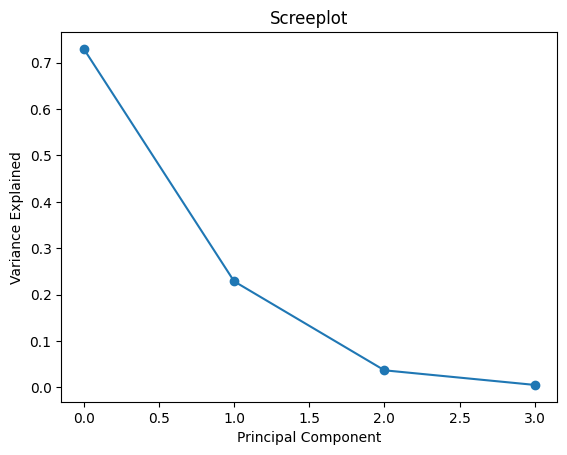

In [14]:
import matplotlib.pyplot as plt

plt.title("Screeplot")

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()

In [15]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
pca_iris = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
pca_iris['class'] = iris['class']

pca_iris.head()

,PC1,PC2,class
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


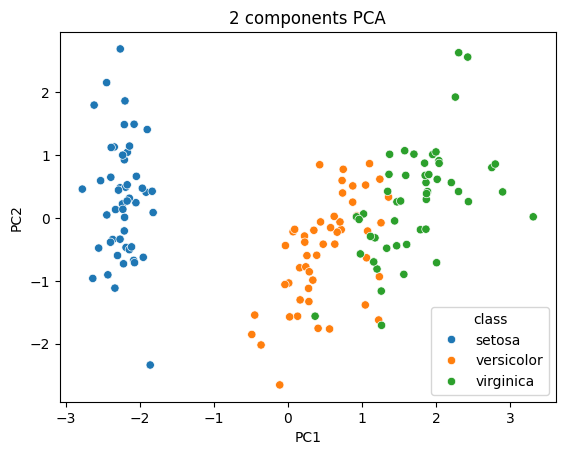

In [17]:
import seaborn as sns

plt.title("2 components PCA")
sns.scatterplot(x='PC1', y='PC2', hue='class', data=pca_iris)
plt.show()